# ADS-509 Assignment 1.1
## Collecting Text Data via API and Web Scraping


## Imports and Definitions

First we import our libraries, set up our folder structure, and define some useful functions and variables.

In [1]:
import os, json, time, random
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Polite scraping: set a clear user agent and throttle requests a bit
HEADERS = {"User-Agent": "MADS-LLM-2025-Student/1.0 (+https://example.edu)"}
BASE = "https://hacker-news.firebaseio.com/v0"

def sleep_politely(sleep_range=(1.0, 2.0)):
    """Sleep for a uniformly random duration within sleep_range (seconds).
    
    Introduces a random pause between requests so we don't hammer
    the server with rapid-fire calls — a basic form of polite scraping.
    """
    duration = random.uniform(*sleep_range)
    time.sleep(duration)

In [3]:
# Define folder structure — update paths here if you want data stored elsewhere
DATA_DIR    = 'data/module1'
RAW_API_DIR = os.path.join(DATA_DIR, 'raw_api')
RAW_HTML_DIR = os.path.join(DATA_DIR, 'raw_html')

for d in [DATA_DIR, RAW_API_DIR, RAW_HTML_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directories ready:', DATA_DIR, RAW_API_DIR, RAW_HTML_DIR)

Directories ready: data/module1 data/module1\raw_api data/module1\raw_html


## API Data Collection

Here we will use the **requests** library to interact with the HackerNews API. Our ultimate goal is to create a dataset with metadata and discussion posts for 50 of the top stories on this website, so first we will use the API to get the top story IDs.

**Q:** What do the `headers` and `timeout` arguments in the requests library do?

**A:** 
- **`headers`**: A dictionary of HTTP request headers sent to the server alongside the request. Common uses include setting the `User-Agent` string (so the server knows who is making the request), passing authentication tokens, or specifying accepted content types. Providing a descriptive `User-Agent` is a matter of good scraping etiquette — it lets site administrators identify your bot and contact you if needed.
- **`timeout`**: Specifies how many seconds `requests` will wait for the server to respond before raising a `requests.exceptions.Timeout` exception. Without a timeout, your script can hang indefinitely if the server is slow or unresponsive. Setting a reasonable value (e.g., `timeout=10`) keeps your pipeline from stalling.

In [4]:
# Get a big list of top story IDs from the HackerNews API
r = requests.get(
    f"{BASE}/topstories.json",
    headers=HEADERS,
    timeout=10
)
r.raise_for_status()
top_ids = r.json()
print('Total top story IDs returned:', len(top_ids))

# For a faster assignment, we'll just use the first 50 stories
CANDIDATE_N = 50
candidate_ids = top_ids[:CANDIDATE_N]
len(candidate_ids), candidate_ids[:5]  # Print 5 of the IDs as a self-check

Total top story IDs returned: 500


(50, [48137145, 48134743, 48136262, 48136240, 48136992])

Next we use our list of article IDs to pull and organize the metadata we want in our final dataset.

In [5]:
def fetch_item(item_id):
    """Fetch a single HN item by ID, caching the JSON to disk.
    
    On subsequent runs the cached file is returned immediately,
    making the pipeline fast and reproducible without re-hitting the API.
    """
    fp = os.path.join(RAW_API_DIR, f"item_{item_id}.json")
    if os.path.exists(fp):
        with open(fp, 'r', encoding='utf-8') as f:
            return json.load(f)
    r = requests.get(
        f"{BASE}/item/{item_id}.json",
        headers=HEADERS,
        timeout=10
    )
    r.raise_for_status()
    data = r.json()
    with open(fp, 'w', encoding='utf-8') as f:
        json.dump(data, f)
    sleep_politely()  # be polite between API calls
    return data


# Fetch metadata for each candidate story
items = []
for idx, i in enumerate(candidate_ids):
    if idx % 5 == 0:
        print(f"{idx}/{len(candidate_ids)}")
    items.append(fetch_item(i))

# Filter to stories that actually have comment threads (descendants > 0)
stories = [
    item for item in items
    if item is not None and item.get("descendants", 0) > 0
]

# Format into a tidy DataFrame, keeping only the columns we need
keep_cols = ["id", "title", "by", "time", "url", "score", "descendants"]
stories_df = pd.json_normalize(stories)[keep_cols]

print('Stories with discussion threads:', len(stories_df))
stories_df.head()

0/50
5/50
10/50
15/50
20/50
25/50
30/50
35/50
40/50
45/50
Stories with discussion threads: 48


,id,title,by,time,url,score,descendants
0,48137145,RTX 5090 and M4 MacBook Air: Can It Game?,allenleee,1778773651,https://scottjg.com/posts/2026-05-05-egpu-mac-...,22,1
1,48134743,Computer Hobby Movement in Canada,rbanffy,1778763447,https://museum.eecs.yorku.ca/exhibits/show/hob...,105,29
2,48136262,MIT: 20% drop in incoming graduate students,dmayo,1778770274,https://president.mit.edu/writing-speeches/vid...,273,266
3,48136240,Claude AI recovers an 11 yrs old BTC wallet ho...,cednore,1778770188,https://www.tomshardware.com/tech-industry/cry...,142,57
4,48136992,On The Conflation of Money and Things,bookofjoe,1778772984,https://lithub.com/is-it-even-real-on-the-conf...,6,1


## Web Scraping

Next, we use our list of story IDs to scrape the discussion threads from HackerNews using BeautifulSoup.

**Q:** Find the HackerNews `robots.txt`. What does it say about scraping, and are we acting within its stated policy?

**A:** 
HackerNews's `robots.txt` (https://news.ycombinator.com/robots.txt) disallows only a small set of paths (e.g., `/x?`, `/r?`, `/vote`, `/reply`, `/submit`, etc.) and explicitly allows the main item pages (`/item`) that we are scraping. The file also requests a crawl delay — typically 30 seconds between requests — which is why `get_discussion_html` uses `sleep_politely(sleep_range=(30.0, 31.0))` rather than the shorter 1–2 second delay used for the API. We are therefore acting within the policy: we scrape only allowed pages, we identify ourselves with a descriptive `User-Agent`, and we respect the requested crawl delay.

In [7]:
def get_discussion_html(story_id, max_retries=3):
    """Fetch and cache the HTML for a HN story's comment page, with retry on 429."""
    fp = os.path.join(RAW_HTML_DIR, f"hn_{story_id}.html")
    if os.path.exists(fp):
        with open(fp, 'r', encoding='utf-8') as f:
            return f.read()
    
    url = f"https://news.ycombinator.com/item?id={story_id}"
    
    for attempt in range(max_retries):
        r = requests.get(url, headers=HEADERS, timeout=15)
        
        if r.status_code == 429:
            wait = 60 * (attempt + 1)  # back off: 60s, 120s, 180s
            print(f"  429 rate-limited on {story_id}. Waiting {wait}s (attempt {attempt+1}/{max_retries})...")
            time.sleep(wait)
            continue
        
        r.raise_for_status()  # raise for any other error (4xx, 5xx)
        html = r.text
        
        with open(fp, 'w', encoding='utf-8') as f:
            f.write(html)
        
        sleep_politely(sleep_range=(30.0, 35.0))  # longer base delay between pages
        return html
    
    print(f"  Skipping {story_id} after {max_retries} failed attempts.")
    return ""   # return empty string so the loop continues


def parse_comments_from_html(html, story_id):
    """Extract comment rows from a HN item page's HTML.
    
    Each top-level and nested comment lives in a <tr class="athing comtr"> row.
    We extract:
      - comment_id  : the unique ID on the <tr> element
      - user        : commenter's username (<a class="hnuser">)
      - time_text   : human-readable age string (<span class="age">)
      - comment_text: plain text of the comment body (<div class="commtext">)
    Comments with no text (e.g. deleted/dead) are skipped.
    """
    soup = BeautifulSoup(html, 'html.parser')
    rows = []

    for tr in soup.find_all("tr", class_="athing comtr"):
        comment_id = tr.get("id")

        # Username
        user_tag = tr.find("a", class_="hnuser")
        user = user_tag.text if user_tag else None

        # Human-readable age (e.g. "3 hours ago")
        time_tag = tr.find("span", class_="age")
        time_text = time_tag.get("title") if time_tag else None  # ISO timestamp in title attr

        # Comment body — get_text collapses nested tags (links, code, etc.) to plain text
        text_tag = tr.find("div", class_="commtext")
        comment_text = (
            text_tag.get_text(" ", strip=True)
            if text_tag else None
        )

        # Skip deleted/dead comments that have no text
        if comment_text:
            rows.append({
                'story_id':    story_id,
                'comment_id':  comment_id,
                'user':        user,
                'time_text':   time_text,
                'comment_text': comment_text,
            })
    return rows


# Scrape all story pages and collect comments
all_comments = []
for idx, sid in enumerate(stories_df['id'].tolist()):
    if idx % 5 == 0:
        print(f"{idx}/{len(stories_df)}")
    html = get_discussion_html(sid)
    all_comments.extend(parse_comments_from_html(html, sid))

comments_df = pd.DataFrame(all_comments)
print('Total comments scraped:', len(comments_df))
comments_df.head()

0/48
5/48
10/48
15/48
20/48
25/48
  429 rate-limited on 48084516. Waiting 60s (attempt 1/3)...
30/48
  429 rate-limited on 48130186. Waiting 60s (attempt 1/3)...
35/48
  429 rate-limited on 48077924. Waiting 60s (attempt 1/3)...
40/48
  429 rate-limited on 48102901. Waiting 60s (attempt 1/3)...
  429 rate-limited on 48102901. Waiting 120s (attempt 2/3)...
  429 rate-limited on 48102901. Waiting 180s (attempt 3/3)...
  Skipping 48102901 after 3 failed attempts.
45/48
  429 rate-limited on 48137437. Waiting 60s (attempt 1/3)...
Total comments scraped: 5665


,story_id,comment_id,user,time_text,comment_text
0,48137145,48137577,frollogaston,2026-05-14T16:20:57 1778775657,I'm guessing the x86 emu is cause Windows game...
1,48137145,48137618,moralestapia,2026-05-14T16:23:45 1778775825,"Wow, phenomenal project and write-up, thanks f..."
2,48134743,48136386,buescher,2026-05-14T14:59:42 1778770782,I got a VIC-20 when I was about 12? Jim Butte...
3,48134743,48137325,bch,2026-05-14T16:01:08 1778774468,I didn't realize he was Canadian - as a child ...
4,48134743,48136690,reaperducer,2026-05-14T15:16:49 1778771809,for some reason resident debuggers were freque...


## Combine Datasets

Now we merge the two DataFrames into a single tidy dataset (one row per comment).

**Q:** If we didn't have a shared key for the two DataFrames in this scenario, what could you use instead to join them?

**A:** Without a shared numeric key we could perform a **fuzzy / approximate join** using story titles. For example, we could normalize both sides (lowercase, strip punctuation) and use string similarity metrics (e.g., Levenshtein distance via `thefuzz`, or TF-IDF cosine similarity) to match story titles in `stories_df` to the page `<title>` element captured during scraping. Alternatively, if both sources expose a canonical URL, that URL could serve as a natural key: the HN API returns the external article URL and the HN item page also displays it, so we could join on `url` after normalizing the strings.

In [8]:
# Merge on the shared story identifier
merged_df = comments_df.merge(
    stories_df,
    left_on='story_id',
    right_on='id',
    how='inner'
)

# Convert Unix epoch timestamp to a proper pandas datetime (UTC)
merged_df['story_time'] = pd.to_datetime(
    merged_df['time'],
    unit='s',
    utc=True
)

# Sanity check: every row should have comment text
assert merged_df['comment_text'].notna().all(), "Some rows are missing comment text!"

print('Rows in merged dataset:', len(merged_df))
merged_df.sample(3)

Rows in merged dataset: 5665


,story_id,comment_id,user,time_text,comment_text,id,title,by,time,url,score,descendants,story_time
1575,48134993,48136071,cogman10,2026-05-14T14:37:25 1778769445,One of the wild things about farming is that c...,48134993,USDA Projects Smallest US Wheat Harvest Since ...,littlexsparkee,1778764677,https://www.agweb.com/news/usda-projects-small...,169,114,2026-05-14 13:17:57+00:00
4727,48130123,48131048,udave,2026-05-14T04:18:10 1778732290,seems like the same trick as behind labelling ...,48130123,Cisco workforce reductions,ahmedomran8,1778722685,https://blogs.cisco.com/news/our-path-forward,244,274,2026-05-14 01:38:05+00:00
2101,48125617,48136598,xhkkffbf,2026-05-14T15:11:24 1778771484,"Now that RAM is getting more expensive, I hope...",48125617,"MacBook Neo Deep Dive: Benchmarks, Wafer Econo...",tosh,1778697051,https://www.jdhodges.com/blog/macbook-neo-benc...,297,356,2026-05-13 18:30:51+00:00


## Save Your Dataset for Future Use

We will be using this dataset in future assignments, so use this code to save it to file.

In [9]:
out_csv = os.path.join(DATA_DIR, 'hn_comments_with_storymeta.csv')
merged_df.to_csv(out_csv, index=False)
print('Saved to:', out_csv)

Saved to: data/module1\hn_comments_with_storymeta.csv


## Validation

This section is used for grading. Please run these cells before submission, but do not change any of the code.

In [10]:
comments_per_story = (
    merged_df.groupby(['story_id', 'title']).size()
    .rename('n_comments').reset_index()
)
comments_per_story.sort_values('n_comments', ascending=False).head(10)

,story_id,title,n_comments
15,48121929,The US is winning the AI race where it matters...,623
7,48087887,Linux gaming is faster because Windows APIs ar...,555
20,48126848,Princeton mandates proctoring for in-person ex...,526
27,48130950,Claude for Small Business,412
19,48125617,"MacBook Neo Deep Dive: Benchmarks, Wafer Econo...",334
0,48073979,A History of IDEs at Google,279
40,48136262,MIT: 20% drop in incoming graduate students,271
24,48130123,Cisco workforce reductions,268
14,48118727,The Emacsification of Software,232
16,48122635,Setting up a free *.city.state.us locality dom...,202


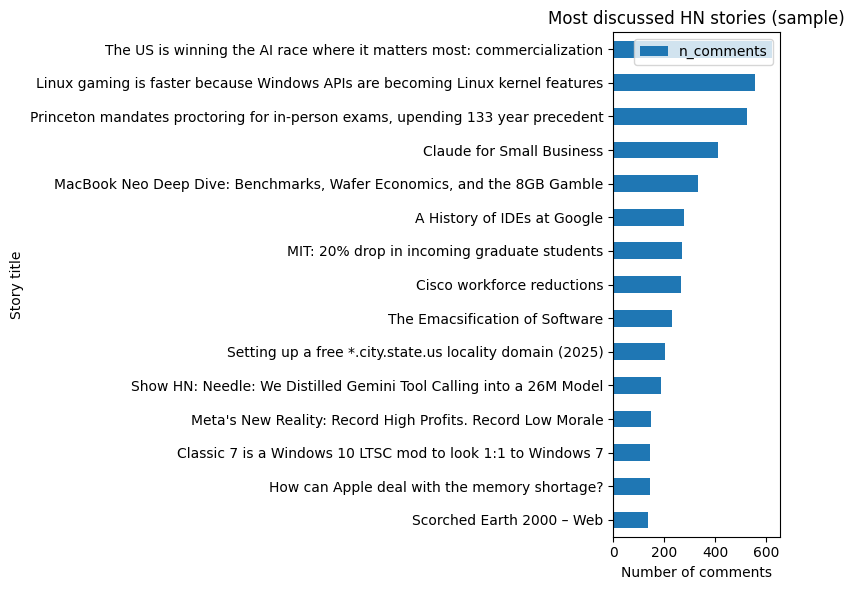

In [11]:
ax = (
    comments_per_story.sort_values('n_comments')
    .tail(15)
    .plot(kind='barh', x='title', y='n_comments', figsize=(8, 6))
)
ax.set_xlabel('Number of comments')
ax.set_ylabel('Story title')
ax.set_title('Most discussed HN stories (sample)')
plt.tight_layout()
plt.show()

In [12]:
merged_df['user'].fillna('unknown').value_counts().head(10)

user
HenryNdubuaku     44
JumpCrisscross    32
tptacek           27
traderj0e         24
Ucalegon          22
marcingas         22
mrhottakes        19
bombcar           17
SubiculumCode     17
iLemming          14
Name: count, dtype: int64

<small>This assignment was designed with the assistance of ChatGPT.</small>